In [1]:
import sys
print(sys.executable)

/Users/yiifann2021/miniforge3/envs/sammoo_mps/bin/python3


In [2]:
import os

!pwd

data_path = "/Users/yiifann2021/Desktop/MEDFAIR_SAMMOO/MEDFAIR_datasets/HAM10000/"

print(os.listdir(data_path))

/Users/yiifann2021/Desktop/MEDFAIR_SAMMOO/notebooks
['split', 'HAM10000_segmentations_lesion_tschandl.zip', '.DS_Store', 'HAM10000_images_part_1.zip', 'HAM10000_images_part_2.zip', 'pkls', 'ISIC2018_Task3_Test_Images.zip', 'ISIC2018_Task3_Test_NatureMedicine_AI_Interaction_Benefit.csv', 'ISIC2018_Task3_Test_GroundTruth.csv', 'HAM10000_images', 'HAM10000_metadata.csv']


In [3]:
import os

metadata_path = os.path.join(data_path, "HAM10000_metadata")

print("是否为文件：", os.path.isfile(metadata_path))
print("是否为文件夹：", os.path.isdir(metadata_path))

if os.path.isfile(metadata_path):
    print("文件大小：", os.path.getsize(metadata_path), "bytes")

if os.path.isdir(metadata_path):
    print("文件夹内容：", os.listdir(metadata_path))

是否为文件： False
是否为文件夹： False


In [4]:
import os
import pandas as pd

metadata_path = os.path.join(data_path, "HAM10000_metadata")

demo_data = pd.read_csv(metadata_path)

print("数据形状：", demo_data.shape)
print("列名：", demo_data.columns.tolist())

demo_data.head()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/yiifann2021/Desktop/MEDFAIR_SAMMOO/MEDFAIR_datasets/HAM10000/HAM10000_metadata'

In [6]:
from pathlib import Path
import zipfile

data_path = Path("../MEDFAIR_datasets/HAM10000")
image_dir = data_path / "HAM10000_images"

# 创建存放全部图片的文件夹
image_dir.mkdir(exist_ok=True)

zip_files = [
    "HAM10000_images_part_1.zip",
    "HAM10000_images_part_2.zip"
]

for zip_name in zip_files:
    zip_path = data_path / zip_name
    
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(image_dir)
        print(f"{zip_name} 解压完成，包含 {len(zip_ref.namelist())} 个文件")

# 检查一共找到了多少张 jpg 图片
jpg_files = list(image_dir.rglob("*.jpg"))

print("图片总数：", len(jpg_files))
print("前几张图片：")
for file in jpg_files[:5]:
    print(file)

HAM10000_images_part_1.zip 解压完成，包含 5000 个文件
HAM10000_images_part_2.zip 解压完成，包含 5015 个文件
图片总数： 10015
前几张图片：
../MEDFAIR_datasets/HAM10000/HAM10000_images/ISIC_0030858.jpg
../MEDFAIR_datasets/HAM10000/HAM10000_images/ISIC_0030680.jpg
../MEDFAIR_datasets/HAM10000/HAM10000_images/ISIC_0033389.jpg
../MEDFAIR_datasets/HAM10000/HAM10000_images/ISIC_0032097.jpg
../MEDFAIR_datasets/HAM10000/HAM10000_images/ISIC_0032929.jpg


In [6]:
# 为每条 metadata 记录添加对应的图片路径
demo_data["Path"] = demo_data["image_id"].apply(
    lambda image_id: f"HAM10000_images/{image_id}.jpg"
)

# 检查 metadata 中记录的图片是否都真实存在
missing_images = []

for relative_path in demo_data["Path"]:
    full_path = data_path / relative_path

    if not full_path.exists():
        missing_images.append(str(full_path))

print("metadata 记录数：", len(demo_data))
print("缺失图片数：", len(missing_images))

demo_data[["image_id", "Path"]].head()

HAM10000_images_part_1.zip 解压完成，包含 5000 个文件
HAM10000_images_part_2.zip 解压完成，包含 5015 个文件
图片总数： 10015
前几张图片：
../MEDFAIR_datasets/HAM10000/HAM10000_images/ISIC_0030858.jpg
../MEDFAIR_datasets/HAM10000/HAM10000_images/ISIC_0030680.jpg
../MEDFAIR_datasets/HAM10000/HAM10000_images/ISIC_0033389.jpg
../MEDFAIR_datasets/HAM10000/HAM10000_images/ISIC_0032097.jpg
../MEDFAIR_datasets/HAM10000/HAM10000_images/ISIC_0032929.jpg


## Real Start (Don't re-run the above cell)

In [15]:
import h5py
import pandas as pd
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
import pickle
import time
from pathlib import Path
import zipfile

## Preprocess metadata

In [3]:
# read metadata
path = '../MEDFAIR_datasets/HAM10000/'

demo_data = pd.read_csv(path + 'HAM10000_metadata.csv')
demo_data

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern
...,...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen,vidir_modern
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen,vidir_modern
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen,vidir_modern
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face,vidir_modern


In [4]:
Counter(demo_data['dataset'])

Counter({'vidir_molemax': 3954,
         'vidir_modern': 3363,
         'rosendahl': 2259,
         'vienna_dias': 439})

In [5]:
# add image path to the metadata
pathlist = demo_data['image_id'].values.tolist()
paths = ['HAM10000_images/' + i + '.jpg' for i in pathlist]
demo_data['Path'] = paths

In [6]:
# remove age/sex == null 
demo_data = demo_data[~demo_data['age'].isnull()]
demo_data = demo_data[~demo_data['sex'].isnull()]
demo_data

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,Path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,HAM10000_images/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern,HAM10000_images/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,HAM10000_images/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern,HAM10000_images/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,HAM10000_images/ISIC_0031633.jpg
...,...,...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen,vidir_modern,HAM10000_images/ISIC_0033084.jpg
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen,vidir_modern,HAM10000_images/ISIC_0033550.jpg
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen,vidir_modern,HAM10000_images/ISIC_0033536.jpg
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face,vidir_modern,HAM10000_images/ISIC_0032854.jpg


In [7]:
# unify the value of sensitive attributes
sex = demo_data['sex'].values
sex[sex == 'male'] = 'M'
sex[sex == 'female'] = 'F'
demo_data['Sex'] = sex
demo_data

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,Path,Sex
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,M,scalp,vidir_modern,HAM10000_images/ISIC_0027419.jpg,M
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,M,scalp,vidir_modern,HAM10000_images/ISIC_0025030.jpg,M
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,M,scalp,vidir_modern,HAM10000_images/ISIC_0026769.jpg,M
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,M,scalp,vidir_modern,HAM10000_images/ISIC_0025661.jpg,M
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,M,ear,vidir_modern,HAM10000_images/ISIC_0031633.jpg,M
...,...,...,...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,M,abdomen,vidir_modern,HAM10000_images/ISIC_0033084.jpg,M
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,M,abdomen,vidir_modern,HAM10000_images/ISIC_0033550.jpg,M
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,M,abdomen,vidir_modern,HAM10000_images/ISIC_0033536.jpg,M
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,M,face,vidir_modern,HAM10000_images/ISIC_0032854.jpg,M


In [8]:
# split subjects to different age groups
demo_data['Age_multi'] = demo_data['age'].values.astype('int')
demo_data['Age_multi'] = np.where(demo_data['Age_multi'].between(-1,19), 0, demo_data['Age_multi'])
demo_data['Age_multi'] = np.where(demo_data['Age_multi'].between(20,39), 1, demo_data['Age_multi'])
demo_data['Age_multi'] = np.where(demo_data['Age_multi'].between(40,59), 2, demo_data['Age_multi'])
demo_data['Age_multi'] = np.where(demo_data['Age_multi'].between(60,79), 3, demo_data['Age_multi'])
demo_data['Age_multi'] = np.where(demo_data['Age_multi']>=80, 4, demo_data['Age_multi'])

demo_data['Age_binary'] = demo_data['age'].values.astype('int')
demo_data['Age_binary'] = np.where(demo_data['Age_binary'].between(-1, 60), 0, demo_data['Age_binary'])
demo_data['Age_binary'] = np.where(demo_data['Age_binary']>= 60, 1, demo_data['Age_binary'])
demo_data

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,Path,Sex,Age_multi,Age_binary
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,M,scalp,vidir_modern,HAM10000_images/ISIC_0027419.jpg,M,4,1
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,M,scalp,vidir_modern,HAM10000_images/ISIC_0025030.jpg,M,4,1
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,M,scalp,vidir_modern,HAM10000_images/ISIC_0026769.jpg,M,4,1
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,M,scalp,vidir_modern,HAM10000_images/ISIC_0025661.jpg,M,4,1
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,M,ear,vidir_modern,HAM10000_images/ISIC_0031633.jpg,M,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,M,abdomen,vidir_modern,HAM10000_images/ISIC_0033084.jpg,M,2,0
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,M,abdomen,vidir_modern,HAM10000_images/ISIC_0033550.jpg,M,2,0
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,M,abdomen,vidir_modern,HAM10000_images/ISIC_0033536.jpg,M,2,0
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,M,face,vidir_modern,HAM10000_images/ISIC_0032854.jpg,M,4,1


In [9]:
# convert to binary labels
# benign: bcc, bkl, dermatofibroma, nv, vasc
# maglinant: akiec, mel

labels = demo_data['dx'].values.copy()
labels[labels == 'akiec'] = '1'
labels[labels == 'mel'] = '1'
labels[labels != '1'] = '0'

labels = labels.astype('int')

demo_data['binaryLabel'] = labels
demo_data

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,Path,Sex,Age_multi,Age_binary,binaryLabel
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,M,scalp,vidir_modern,HAM10000_images/ISIC_0027419.jpg,M,4,1,0
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,M,scalp,vidir_modern,HAM10000_images/ISIC_0025030.jpg,M,4,1,0
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,M,scalp,vidir_modern,HAM10000_images/ISIC_0026769.jpg,M,4,1,0
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,M,scalp,vidir_modern,HAM10000_images/ISIC_0025661.jpg,M,4,1,0
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,M,ear,vidir_modern,HAM10000_images/ISIC_0031633.jpg,M,3,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,M,abdomen,vidir_modern,HAM10000_images/ISIC_0033084.jpg,M,2,0,1
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,M,abdomen,vidir_modern,HAM10000_images/ISIC_0033550.jpg,M,2,0,1
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,M,abdomen,vidir_modern,HAM10000_images/ISIC_0033536.jpg,M,2,0,1
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,M,face,vidir_modern,HAM10000_images/ISIC_0032854.jpg,M,4,1,1


## Split train/val/test

In [10]:
def split_811(all_meta, patient_ids):
    sub_train, sub_val_test = train_test_split(patient_ids, test_size=0.2, random_state=0)
    sub_val, sub_test = train_test_split(sub_val_test, test_size=0.5, random_state=0)
    train_meta = all_meta[all_meta.lesion_id.isin(sub_train)]
    val_meta = all_meta[all_meta.lesion_id.isin(sub_val)]
    test_meta = all_meta[all_meta.lesion_id.isin(sub_test)]
    return train_meta, val_meta, test_meta

sub_train, sub_val, sub_test = split_811(demo_data, np.unique(demo_data['lesion_id']))

In [16]:
data_path = Path("../MEDFAIR_datasets/HAM10000")

new_dataset_dir = data_path / "split"
new_dataset_dir.mkdir(exist_ok=True)

sub_train.to_csv('../MEDFAIR_datasets/HAM10000/split/new_train.csv')
sub_val.to_csv('../MEDFAIR_datasets/HAM10000/split/new_val.csv')
sub_test.to_csv('../MEDFAIR_datasets/HAM10000/split/new_test.csv')

(450, 600, 3)


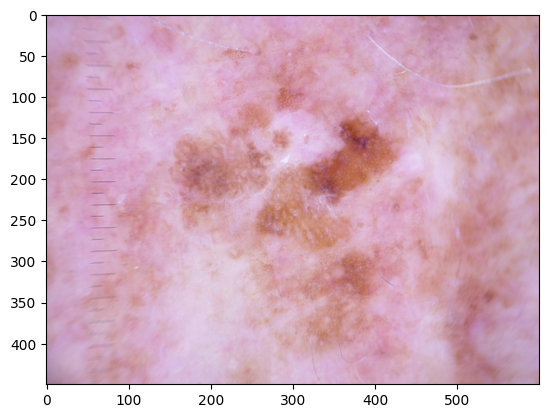

In [17]:
# you can have a look of some examples here
img = cv2.imread('../MEDFAIR_datasets/HAM10000/HAM10000_images/ISIC_0027419.jpg')
print(img.shape)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

## Save images into pickle files
This is optional, but if you are training many models, this step can save a lot of time by reducing the data IO.

In [21]:
pkl_dir = Path("../MEDFAIR_datasets/HAM10000/pkls")
pkl_dir.mkdir(parents=True, exist_ok=True)

In [22]:
test_meta = pd.read_csv('../MEDFAIR_datasets/HAM10000/split/new_train.csv')

print("1")

path = '../MEDFAIR_datasets/HAM10000/pkls/'
path_1 = '../MEDFAIR_datasets/HAM10000/'
images = []
start = time.time()
print(start)
for i in range(len(test_meta)):

    img = cv2.imread(path_1 + test_meta.iloc[i]['Path'])
    # resize to the input size in advance to save time during training
    img = cv2.resize(img, (256, 256))
    images.append(img)
    
end = time.time()
print(end)
end-start

with open(path + 'train_images.pkl', 'wb') as f:
    pickle.dump(images, f)

1
1783378738.992384
1783378767.9250119


In [23]:
test_meta = pd.read_csv('../MEDFAIR_datasets/HAM10000/split/new_val.csv')

print("2")

path = '../MEDFAIR_datasets/HAM10000/pkls/'
path_1 = '../MEDFAIR_datasets/HAM10000/'
images = []
start = time.time()
print(start)
for i in range(len(test_meta)):

    img = cv2.imread(path_1 + test_meta.iloc[i]['Path'])
    # resize to the input size in advance to save time during training
    img = cv2.resize(img, (256, 256))
    images.append(img)
    
end = time.time()
print(end)
end-start

with open(path + 'val_images.pkl', 'wb') as f:
    pickle.dump(images, f)

2
1783378831.92172
1783378835.611201


In [24]:
test_meta = pd.read_csv('../MEDFAIR_datasets/HAM10000/split/new_test.csv')

print("3")

path = '../MEDFAIR_datasets/HAM10000/pkls/'
path_1 = '../MEDFAIR_datasets/HAM10000/'
images = []
start = time.time()
print(start)
for i in range(len(test_meta)):

    img = cv2.imread(path_1 + test_meta.iloc[i]['Path'])
    # resize to the input size in advance to save time during training
    img = cv2.resize(img, (256, 256))
    images.append(img)
    
end = time.time()
print(end)
end-start

with open(path + 'test_images.pkl', 'wb') as f:
    pickle.dump(images, f)

3
1783378842.086524
1783378845.7728581


In [1]:
import json
import pickle
import pandas as pd
from pathlib import Path

# 读取你刚刚修改好的数据配置
with open("../configs/datasets.json", "r") as f:
    config = json.load(f)["HAM10000"]

pairs = [
    ("train", config["train_meta_path"], config["pickle_train_path"]),
    ("val", config["val_meta_path"], config["pickle_val_path"]),
    ("test", config["test_meta_path"], config["pickle_test_path"]),
]

for split_name, csv_path, pkl_path in pairs:
    csv_path = Path(csv_path)
    pkl_path = Path(pkl_path)

    print(f"\n检查 {split_name} 数据集")
    print("CSV 是否存在：", csv_path.exists())
    print("PKL 是否存在：", pkl_path.exists())

    metadata = pd.read_csv(csv_path)

    with open(pkl_path, "rb") as f:
        images = pickle.load(f)

    print("CSV 样本数量：", len(metadata))
    print("PKL 图片数量：", len(images))
    print("数量是否一致：", len(metadata) == len(images))
    print("第一张图片形状：", images[0].shape)

    # 避免三个 pickle 同时占用内存
    del images


检查 train 数据集
CSV 是否存在： True
PKL 是否存在： True
CSV 样本数量： 7967
PKL 图片数量： 7967
数量是否一致： True
第一张图片形状： (256, 256, 3)

检查 val 数据集
CSV 是否存在： True
PKL 是否存在： True
CSV 样本数量： 989
PKL 图片数量： 989
数量是否一致： True
第一张图片形状： (256, 256, 3)

检查 test 数据集
CSV 是否存在： True
PKL 是否存在： True
CSV 样本数量： 1002
PKL 图片数量： 1002
数量是否一致： True
第一张图片形状： (256, 256, 3)
